# Re-evaluate one baseline Pareto front at modified transmissivity

This notebook takes the **final feasible Pareto-front members** from one baseline MOU run, re-evaluates those **same pumping solutions** at:

- baseline transmissivity
- **+10% T**
- **-10% T**

and then saves:

- member-level reevaluation tables
- tradeoff tables
- summary-statistics tables
- comparison plots in `project_output/<run_name>/`

This notebook is set up for **one run at a time**, so it is easier to reuse for future models.


## 1) User settings

Only change the values in the next cell.

A few notes:

- `RUN_NAME` should be the name **without** the `run_` prefix.
- `PUMPING_SIGN` should stay `1.0` if your pumping values are already positive.
- If your pumping values are stored as **negative withdrawals**, change `PUMPING_SIGN` to `-1.0`.
- `TRADEOFF_MODE = "sum"` means the plotted depletion metric is the **sum of all `:bdpl` columns**.
- If you want to plot a single observation instead, use `TRADEOFF_MODE = "selected_obs"` and set `TRADEOFF_OBS`.

- This version assumes the required Pareto summary and decision-variable population files are stored as `.zip` files.


In [2]:
from pathlib import Path
import copy
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt

from pycap.analysis_project import Project

# ---------------------------
# user settings
# ---------------------------
RUN_NAME = "fish_dollars_baseline_0.0_1.0_0.01"

SCENARIOS = {
    "baseline": 1.00,
    "Tplus10per": 1.10,
    "Tmin10per": 0.90,
}

BASELINE_FLOW_CFS = 8.6          # set to None to skip the streamflow plot/column
PUMPING_SIGN = 1.0               # use -1.0 if Q values are stored as negative pumping
Q_TO_CFS = 0.002228              # convert pumping from gpm to cfs
TRADEOFF_MODE = "selected_obs"   # "sum" or "selected_obs"
TRADEOFF_OBS = "lpr:total_combined:bdpl"  # recommended for depletion-vs-pumping runs

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
RUN_DIR = PROJECT_DIR / "pycap_runs" / "pycap_pest" / f"run_{RUN_NAME}"
OUTPUT_DIR = NOTEBOOK_DIR / "project_output" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_STATS = ["mean", "std", "25%", "50%", "75%", "max"]

print("RUN_DIR:", RUN_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


RUN_DIR: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/fish_dollars_baseline_0.0_1.0_0.01


## 2) Helper functions

In [ ]:

def load_pareto_archive_summary(run_name, run_dir):
    run_dir = Path(run_dir)
    pareto_file = run_dir / f"{run_name}.pareto.archive.summary.csv.zip"
    if not pareto_file.exists():
        raise FileNotFoundError(f"Could not find required zip file: {pareto_file}")
    return pd.read_csv(pareto_file), pareto_file


def load_final_feasible_pareto_front(run_name, run_dir):
    pareto_df, pareto_file = load_pareto_archive_summary(run_name, run_dir)

    required_cols = {"member", "generation", "nsga2_front", "is_feasible"}
    missing_cols = required_cols - set(pareto_df.columns)
    if missing_cols:
        raise KeyError(f"Pareto summary file is missing required columns: {sorted(missing_cols)}")

    pareto_df = pareto_df.loc[
        (pareto_df["nsga2_front"] == 1) &
        (pareto_df["is_feasible"] == 1)
    ].copy()

    pareto_df["member"] = pareto_df["member"].astype(str)

    final_generation = pareto_df["generation"].max()
    pareto_df_final = pareto_df.loc[
        pareto_df["generation"] == final_generation
    ].copy()

    if pareto_df_final.empty:
        raise ValueError("No feasible Pareto members were found in the final generation.")

    return pareto_df_final, pareto_file, final_generation


def load_decision_variable_population(run_dir):
    run_dir = Path(run_dir)

    dv_files = sorted(run_dir.glob("*dv_pop.csv.zip"))
    if not dv_files:
        raise FileNotFoundError(f"No zipped dv_pop files were found in {run_dir}")

    frames = [pd.read_csv(f, index_col=0) for f in dv_files]

    init_file = run_dir / "initial_dvpop.csv"
    if init_file.exists():
        frames.append(pd.read_csv(init_file, index_col=0))

    dv_df = pd.concat(frames, axis=0)
    dv_df.index = dv_df.index.astype(str)
    dv_df = dv_df[~dv_df.index.duplicated(keep="first")]

    return dv_df


def get_q_columns(df):
    return [c for c in df.columns if "_q" in str(c).lower()]


def load_base_dict(run_dir):
    yml_file = Path(run_dir) / "LPR_Redux.yml"
    if not yml_file.exists():
        raise FileNotFoundError(f"Could not find {yml_file}")
    with open(yml_file, "r") as f:
        return yaml.safe_load(f)


def _flatten_stream_table(df):
    """
    Convert a stream-depletion table with rows like 418, total_combined
    and columns like LPR into a Series indexed as lpr:418:bdpl, etc.
    """
    out = {}
    for row_name in df.index:
        for col_name in df.columns:
            obs_name = f"{str(col_name).lower()}:{str(row_name)}:bdpl"
            out[obs_name] = df.loc[row_name, col_name]
    return pd.Series(out, dtype=float)


def _normalize_stream_name(stream_name):
    return str(stream_name).split(":")[0]


def _build_bdpl_series_from_wells(ap, initial_dict):
    """
    Manual fallback for pycap versions that do not expose agg_base_stream_df.

    Builds the equivalent of the base-stream depletion table by taking the
    maximum depletion for each well-stream pair, converting to cfs, and then
    summing into total_existing, total_proposed, and total_combined rows.
    """
    if not hasattr(ap, "wells"):
        raise AttributeError("Project object has no 'wells' attribute for manual fallback.")

    rows = {}
    total_existing = {}
    total_proposed = {}
    total_combined = {}

    for well_key, well_obj in ap.wells.items():
        if not hasattr(well_obj, "depletion"):
            continue

        if well_key in initial_dict and isinstance(initial_dict[well_key], dict):
            well_label = str(initial_dict[well_key].get("name", well_key))
            status = str(initial_dict[well_key].get("status", "pending")).lower()
        else:
            well_label = str(getattr(well_obj, "name", well_key))
            status = str(getattr(well_obj, "status", "pending")).lower()

        row = {}

        for stream_name, ts in well_obj.depletion.items():
            base_stream = _normalize_stream_name(stream_name)
            arr = np.asarray(ts, dtype=float)
            max_depl_cfs = float(np.nanmax(arr) / (3600.0 * 24.0))

            row[base_stream] = row.get(base_stream, 0.0) + max_depl_cfs
            total_combined[base_stream] = total_combined.get(base_stream, 0.0) + max_depl_cfs

            if status == "existing":
                total_existing[base_stream] = total_existing.get(base_stream, 0.0) + max_depl_cfs
            else:
                total_proposed[base_stream] = total_proposed.get(base_stream, 0.0) + max_depl_cfs

        rows[well_label] = row

    stream_df = pd.DataFrame.from_dict(rows, orient="index").fillna(0.0)

    if total_existing:
        stream_df.loc["total_existing", list(total_existing.keys())] = pd.Series(total_existing)
    if total_proposed:
        stream_df.loc["total_proposed", list(total_proposed.keys())] = pd.Series(total_proposed)
    if total_combined:
        stream_df.loc["total_combined", list(total_combined.keys())] = pd.Series(total_combined)

    stream_df = stream_df.fillna(0.0)
    return _flatten_stream_table(stream_df)


def _extract_bdpl_series_from_project(ap, initial_dict):
    """
    Robustly extract bdpl-style results from Project output across different
    pycap versions.
    """
    # First try in-memory aggregate tables
    if hasattr(ap, "agg_base_stream_df") and isinstance(ap.agg_base_stream_df, pd.DataFrame):
        return _flatten_stream_table(ap.agg_base_stream_df.copy())

    if hasattr(ap, "agg_df") and isinstance(ap.agg_df, pd.DataFrame):
        agg_df = ap.agg_df.copy()
        depl_cols = [c for c in agg_df.columns if ":depl" in str(c).lower()]
        if depl_cols:
            out = {}
            for row_name in agg_df.index:
                for col_name in depl_cols:
                    river_name = str(col_name).split(":")[0].lower()
                    obs_name = f"{river_name}:{str(row_name)}:bdpl"
                    out[obs_name] = agg_df.loc[row_name, col_name]
            return pd.Series(out, dtype=float)

    # Next try writing/reading csv outputs
    if hasattr(ap, "report_responses"):
        try:
            ap.report_responses()
        except Exception:
            pass

    if hasattr(ap, "write_responses_csv"):
        try:
            ap.write_responses_csv()
        except Exception:
            pass

    for attr_name in ["csv_stream_output_filename", "csv_output_filename"]:
        if hasattr(ap, attr_name):
            candidate = Path(getattr(ap, attr_name))
            if candidate.exists():
                candidate_df = pd.read_csv(candidate, index_col=0)
                if "base_stream_depletion" in candidate.name.lower():
                    return _flatten_stream_table(candidate_df)
                depl_cols = [c for c in candidate_df.columns if ":depl" in str(c).lower()]
                if depl_cols:
                    out = {}
                    for row_name in candidate_df.index:
                        for col_name in depl_cols:
                            river_name = str(col_name).split(":")[0].lower()
                            obs_name = f"{river_name}:{str(row_name)}:bdpl"
                            out[obs_name] = candidate_df.loc[row_name, col_name]
                    return pd.Series(out, dtype=float)

    # Final fallback: compute the stream depletion table directly from ap.wells
    return _build_bdpl_series_from_wells(ap, initial_dict)


def get_results_with_T(pars, initial_dict, bdplobs=None, T_multiplier=1.0, write_csv=False):
    pars = pars.copy()
    pars.index = [str(i).lower() for i in pars.index]

    qpars = pars.loc[pars.index.str.contains("_q")]

    upd_dict = copy.deepcopy(initial_dict)

    upd_dict["project_properties"]["T"] = initial_dict["project_properties"]["T"] * T_multiplier

    if "Max_T" in upd_dict["project_properties"]:
        upd_dict["project_properties"]["Max_T"] = initial_dict["project_properties"]["Max_T"] * T_multiplier
    if "Min_T" in upd_dict["project_properties"]:
        upd_dict["project_properties"]["Min_T"] = initial_dict["project_properties"]["Min_T"] * T_multiplier

    for idx, val in qpars.items():
        well_key = idx.split("__")[0]
        upd_dict[well_key]["Q"] = val

    ap = Project(
        None,
        write_results_to_files=write_csv,
        project_dict=upd_dict
    )

    if hasattr(ap, "aggregate_results"):
        try:
            ap.aggregate_results()
        except Exception:
            pass

    if hasattr(ap, "report_responses"):
        try:
            ap.report_responses()
        except Exception:
            pass

    result_series = _extract_bdpl_series_from_project(ap, upd_dict)
    result_series.index = result_series.index.astype(str)

    if bdplobs is not None:
        result_series = result_series.loc[bdplobs]

    return result_series


def reevaluate_member_set(member_q_df, base_dict, scenario_name, T_multiplier, print_every=10):
    results = {}

    for i, (member, row) in enumerate(member_q_df.iterrows(), start=1):
        if (i == 1) or (i % print_every == 0) or (i == len(member_q_df)):
            print(f"{scenario_name}: member {i} of {len(member_q_df)}")
        results[str(member)] = get_results_with_T(
            row,
            base_dict,
            T_multiplier=T_multiplier,
            write_csv=False
        )

    scenario_df = pd.DataFrame(results).T
    scenario_df.index = scenario_df.index.astype(str)
    scenario_df.index.name = "member"
    scenario_df["scenario"] = scenario_name
    scenario_df["T_multiplier"] = T_multiplier

    return scenario_df


def get_bdpl_columns(df):
    return [c for c in df.columns if str(c).endswith(":bdpl")]


def add_tradeoff_metrics(df, member_q_df, pumping_sign=1.0, q_to_cfs=1.0, tradeoff_mode="sum", tradeoff_obs=None, baseline_flow_cfs=None):
    out = df.copy()

    q_cols = get_q_columns(member_q_df)
    if not q_cols:
        raise ValueError("No pumping decision-variable columns containing '_q' were found.")

    total_pumping = pumping_sign * member_q_df[q_cols].sum(axis=1) * q_to_cfs
    total_pumping.index = total_pumping.index.astype(str)
    out["total_pumping_cfs"] = total_pumping.reindex(out.index)

    bdpl_cols = get_bdpl_columns(out)
    if not bdpl_cols:
        raise ValueError("No ':bdpl' columns were found in the reevaluated results.")

    if tradeoff_mode == "sum":
        out["depletion_metric_cfs"] = out[bdpl_cols].sum(axis=1)
        out["depletion_metric_source"] = "sum_of_all_bdpl_columns"
    elif tradeoff_mode == "selected_obs":
        if tradeoff_obs is None:
            raise ValueError("TRADEOFF_OBS must be set when TRADEOFF_MODE = 'selected_obs'.")
        if tradeoff_obs not in out.columns:
            raise KeyError(
                f"TRADEOFF_OBS '{tradeoff_obs}' was not found in the results. "
                f"Available bdpl columns include: {bdpl_cols[:10]}"
            )
        out["depletion_metric_cfs"] = out[tradeoff_obs]
        out["depletion_metric_source"] = tradeoff_obs
    else:
        raise ValueError("TRADEOFF_MODE must be either 'sum' or 'selected_obs'.")

    if baseline_flow_cfs is not None:
        out["streamflow_metric_cfs"] = baseline_flow_cfs - out["depletion_metric_cfs"]

    return out


def make_describe_table(df, value_cols, percentiles=(0.25, 0.50, 0.75)):
    desc = df[value_cols].describe(percentiles=list(percentiles)).loc[SUMMARY_STATS].copy()
    desc.index.name = "statistic"
    return desc


def make_summary_by_scenario(tradeoff_df, value_cols):
    pieces = []
    for scenario, grp in tradeoff_df.groupby("scenario", sort=False):
        desc = make_describe_table(grp, value_cols)
        desc["scenario"] = scenario
        desc = desc.reset_index()
        pieces.append(desc)

    summary_df = pd.concat(pieces, axis=0, ignore_index=True)
    return summary_df


def make_member_level_deltas(tradeoff_df, value_cols):
    baseline_df = (
        tradeoff_df.loc[tradeoff_df["scenario"] == "baseline", ["member"] + value_cols]
        .copy()
        .set_index("member")
        .sort_index()
    )

    delta_frames = []
    for scenario in [s for s in tradeoff_df["scenario"].unique() if s != "baseline"]:
        scenario_df = (
            tradeoff_df.loc[tradeoff_df["scenario"] == scenario, ["member"] + value_cols]
            .copy()
            .set_index("member")
            .sort_index()
        )

        aligned = scenario_df[value_cols] - baseline_df[value_cols]
        aligned["member"] = aligned.index
        aligned["scenario"] = scenario
        delta_frames.append(aligned.reset_index(drop=True))

    if delta_frames:
        delta_df = pd.concat(delta_frames, axis=0, ignore_index=True)
    else:
        delta_df = pd.DataFrame(columns=["member", "scenario"] + value_cols)

    return delta_df


def make_delta_summary(delta_df, value_cols):
    pieces = []
    for scenario, grp in delta_df.groupby("scenario", sort=False):
        desc = make_describe_table(grp, value_cols)
        desc["scenario"] = scenario
        desc = desc.reset_index()
        pieces.append(desc)

    if pieces:
        return pd.concat(pieces, axis=0, ignore_index=True)
    return pd.DataFrame(columns=["statistic", "scenario"] + value_cols)


## 3) Load the final baseline Pareto front and the matching pumping members

In [4]:
pareto_df_final, pareto_file, final_generation = load_final_feasible_pareto_front(RUN_NAME, RUN_DIR)
dv_df = load_decision_variable_population(RUN_DIR)
base_dict = load_base_dict(RUN_DIR)

pareto_members = pareto_df_final["member"].astype(str).tolist()
missing_members = [m for m in pareto_members if m not in dv_df.index.astype(str)]

if missing_members:
    raise KeyError(
        f"{len(missing_members)} Pareto members were not found in the dv_pop files. "
        f"First few missing members: {missing_members[:5]}"
    )

member_q_df = dv_df.copy()
member_q_df.index = member_q_df.index.astype(str)
member_q_df = member_q_df.loc[pareto_members].copy()

q_cols = get_q_columns(member_q_df)
raw_total_pumping = member_q_df[q_cols].sum(axis=1)

print("Pareto summary file:", pareto_file.name)
print("Final generation:", final_generation)
print("Number of final feasible Pareto members:", len(pareto_members))
print("Number of pumping columns:", len(q_cols))
print("Base T:", base_dict["project_properties"]["T"])

if raw_total_pumping.median() < 0 and PUMPING_SIGN == 1.0:
    print("Warning: raw total pumping is negative. If you want positive pumping on the plots, set PUMPING_SIGN = -1.0.")

pareto_df_final.head()


Pareto summary file: fish_dollars_baseline_0.0_1.0_0.01.pareto.archive.summary.csv.zip
Final generation: 50
Number of final feasible Pareto members: 174
Number of pumping columns: 327
Base T: 1700.0


,generation,member,ag_receipts,fish_prob,nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
5486,50,gen=47_member=5907_pso,9738960.0,0.719193,1,1.000000e+30,0.000002,0.000002,1,-999
5487,50,56,12446400.0,0.533346,1,1.000000e+30,0.000005,0.000005,1,-999
5488,50,64,12377800.0,0.567550,1,1.714570e-01,0.000008,0.000008,1,-999
5489,50,gen=40_member=5105_pso,12283000.0,0.583854,1,3.255550e-02,0.000016,0.000016,1,-999
5490,50,30,12433400.0,0.544694,1,1.239110e-01,0.000006,0.000006,1,-999


## 4) Re-evaluate the same Pareto members at baseline, +10% T, and -10% T

In [5]:
scenario_results = {}

for scenario_name, T_multiplier in SCENARIOS.items():
    scenario_results[scenario_name] = reevaluate_member_set(
        member_q_df=member_q_df,
        base_dict=base_dict,
        scenario_name=scenario_name,
        T_multiplier=T_multiplier,
        print_every=25
    )


baseline: member 1 of 174
baseline: member 25 of 174
baseline: member 50 of 174
baseline: member 75 of 174
baseline: member 100 of 174
baseline: member 125 of 174
baseline: member 150 of 174
baseline: member 174 of 174
Tplus10per: member 1 of 174
Tplus10per: member 25 of 174
Tplus10per: member 50 of 174
Tplus10per: member 75 of 174
Tplus10per: member 100 of 174
Tplus10per: member 125 of 174
Tplus10per: member 150 of 174
Tplus10per: member 174 of 174
Tmin10per: member 1 of 174
Tmin10per: member 25 of 174
Tmin10per: member 50 of 174
Tmin10per: member 75 of 174
Tmin10per: member 100 of 174
Tmin10per: member 125 of 174
Tmin10per: member 150 of 174
Tmin10per: member 174 of 174


## 5) Build full output tables and tradeoff tables

In [ ]:
pareto_meta = pareto_df_final.copy()
pareto_meta["member"] = pareto_meta["member"].astype(str)
pareto_meta = pareto_meta.set_index("member")

# Drop any columns from the archived Pareto table that also appear in the
# reevaluated scenario outputs so the reevaluated values are the ones kept.
scenario_result_cols = set()
for scenario_df in scenario_results.values():
    scenario_result_cols.update(
        c for c in scenario_df.columns if c not in ["scenario", "T_multiplier"]
    )

pareto_meta_nonoverlap = pareto_meta.drop(
    columns=[c for c in pareto_meta.columns if c in scenario_result_cols],
    errors="ignore"
)

full_results = {}
tradeoff_frames = []

for scenario_name, scenario_df in scenario_results.items():
    scenario_values = scenario_df.drop(columns=["scenario", "T_multiplier"], errors="ignore")

    full_df = pareto_meta_nonoverlap.join(
        scenario_values,
        how="left"
    )

    full_df["scenario"] = scenario_name
    full_df["T_multiplier"] = SCENARIOS[scenario_name]

    full_df = add_tradeoff_metrics(
        df=full_df,
        member_q_df=member_q_df,
        pumping_sign=PUMPING_SIGN,
        q_to_cfs=Q_TO_CFS,
        tradeoff_mode=TRADEOFF_MODE,
        tradeoff_obs=TRADEOFF_OBS,
        baseline_flow_cfs=BASELINE_FLOW_CFS
    )

    full_results[scenario_name] = full_df.copy()

    plot_cols = ["scenario", "T_multiplier", "total_pumping_cfs", "depletion_metric_cfs", "depletion_metric_source"]
    if "streamflow_metric_cfs" in full_df.columns:
        plot_cols.append("streamflow_metric_cfs")

    tradeoff_frames.append(
        full_df.reset_index()[["member"] + plot_cols].copy()
    )

tradeoff_df = pd.concat(tradeoff_frames, axis=0, ignore_index=True)

summary_value_cols = ["total_pumping_cfs", "depletion_metric_cfs"]
if "streamflow_metric_cfs" in tradeoff_df.columns:
    summary_value_cols.append("streamflow_metric_cfs")

tradeoff_summary_df = make_summary_by_scenario(tradeoff_df, summary_value_cols)
tradeoff_delta_df = make_member_level_deltas(tradeoff_df, summary_value_cols)
tradeoff_delta_summary_df = make_delta_summary(tradeoff_delta_df, summary_value_cols)

tradeoff_summary_df

In [7]:
tradeoff_df.groupby("scenario")[["total_pumping_cfs", "depletion_metric_cfs"]].mean()

,total_pumping_cfs,depletion_metric_cfs
scenario,,
Tmin10per,108.412962,3.007499
Tplus10per,108.412962,3.381715
baseline,108.412962,3.200409


## 6) Plot the baseline Pareto front against the +10% and -10% reevaluations

In [32]:
scen_dfs = tradeoff_df.groupby("scenario", sort=False)
baseline = scen_dfs.get_group("baseline")
min10 = scen_dfs.get_group("Tmin10per")
plus10 = scen_dfs.get_group("Tplus10per")

base_05 = pd.read_csv("/workspaces/LPR_redux/LPR_pycap_opt/notebooks/fish_dollars_baseline_0.0_1.0_0.01_tradeoff.csv")
plus_05 =     pd.read_csv("/workspaces/LPR_redux/LPR_pycap_opt/notebooks/fish_dollars_Tplus10per_0.0_1.0_0.01_tradeoff.csv")
minus_05 =    pd.read_csv("/workspaces/LPR_redux/LPR_pycap_opt/notebooks/fish_dollars_Tmin10per_0.0_1.0_0.01_tradeoff.csv")

#### Full Depletion plot

baseline
Tplus10per
Tmin10per


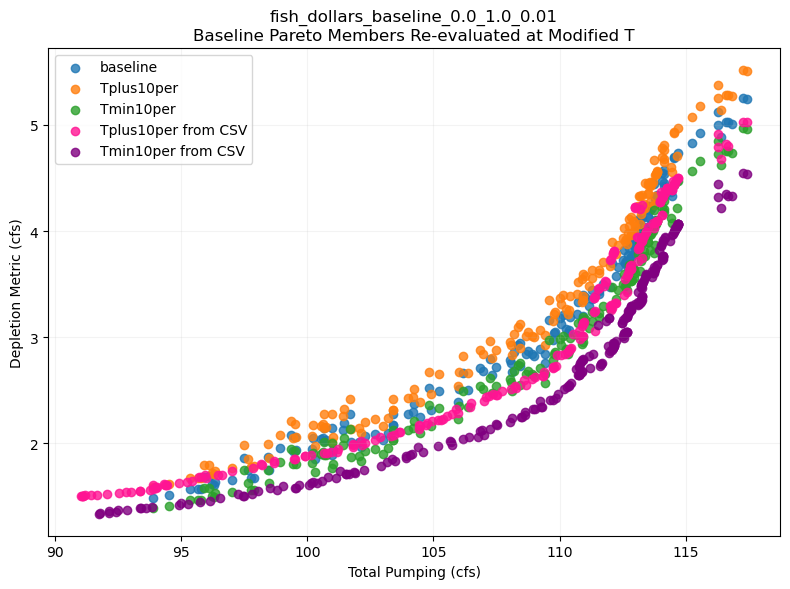

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/fish_dollars_baseline_0.0_1.0_0.01/fish_dollars_baseline_0.0_1.0_0.01_baseline_vs_Tpm10_depletion_plot.png


In [33]:
dx0, dy0 = base_05["Total Pumping (cfs)"], base_05["Depletion (cfs)"]
dx1, dy1 = plus_05["Total Pumping (cfs)"], plus_05["Depletion (cfs)"]
dx2, dy2 = minus_05["Total Pumping (cfs)"], minus_05["Depletion (cfs)"]

plt.figure(figsize=(8, 6))

for scenario_name, grp in tradeoff_df.groupby("scenario", sort=False):
    print(scenario_name)
    plt.scatter(
        grp["total_pumping_cfs"],
        grp["depletion_metric_cfs"],
        label=scenario_name,
        alpha=0.8
    )

plt.scatter(dx1, dy1, color="deeppink", alpha=0.8, label="Tplus10per from CSV")
plt.scatter(dx2, dy2, color="purple", alpha=0.8, label="Tmin10per from CSV")

plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Depletion Metric (cfs)")
plt.title(f"{RUN_NAME}\nBaseline Pareto Members Re-evaluated at Modified T")
plt.legend()
plt.grid(True, alpha=0.15)
plt.tight_layout()

depletion_plot_file = OUTPUT_DIR / f"{RUN_NAME}_baseline_vs_Tpm10_depletion_plot.png"
plt.savefig(depletion_plot_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", depletion_plot_file)


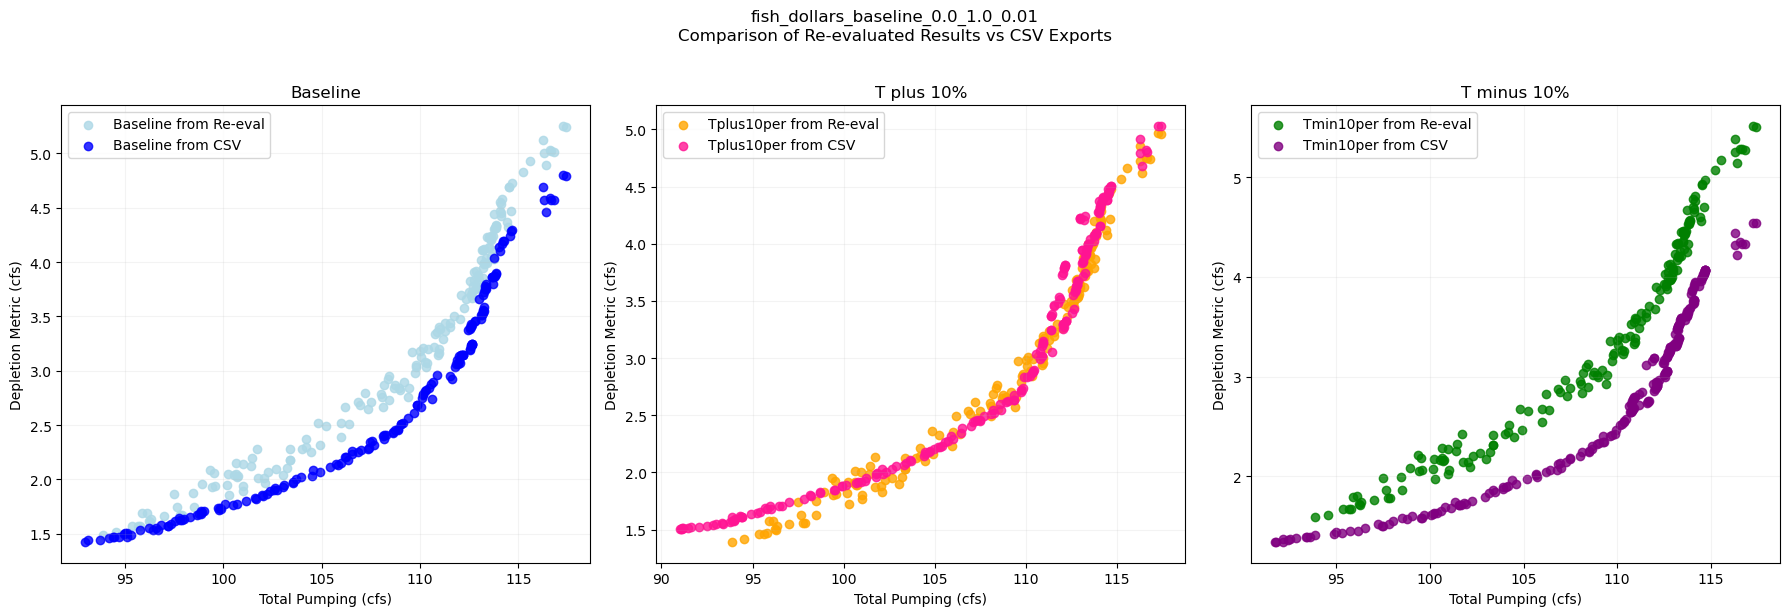

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

axes[0].scatter(baseline["total_pumping_cfs"], baseline["depletion_metric_cfs"], color="lightblue", alpha=0.8, label="Baseline from Re-eval")
axes[0].scatter(dx0, dy0, color="blue", alpha=0.8, label="Baseline from CSV")

axes[1].scatter(min10["total_pumping_cfs"], min10["depletion_metric_cfs"], color="orange", alpha=0.8, label="Tplus10per from Re-eval")
axes[1].scatter(dx1, dy1, color="deeppink", alpha=0.8, label="Tplus10per from CSV")

axes[2].scatter(plus10["total_pumping_cfs"], plus10["depletion_metric_cfs"], color="green", alpha=0.8, label="Tmin10per from Re-eval")
axes[2].scatter(dx2, dy2, color="purple", alpha=0.8, label="Tmin10per from CSV")

for ax in axes:
    ax.set_xlabel("Total Pumping (cfs)")
    ax.set_ylabel("Depletion Metric (cfs)")
    ax.grid(True, alpha=0.15)
    ax.legend() 
    
axes[0].set_title("Baseline")
axes[1].set_title("T plus 10%")
axes[2].set_title("T minus 10%")
plt.suptitle(f"{RUN_NAME}\nComparison of Re-evaluated Results vs CSV Exports", y=1.02)
plt.tight_layout()

comparison_plot_file = OUTPUT_DIR / f"{RUN_NAME}_depletion_comparison_reval_vs_csv.png"
plt.savefig(comparison_plot_file, dpi=300, bbox_inches="tight")
plt.show()


#### Full Streamflow plot

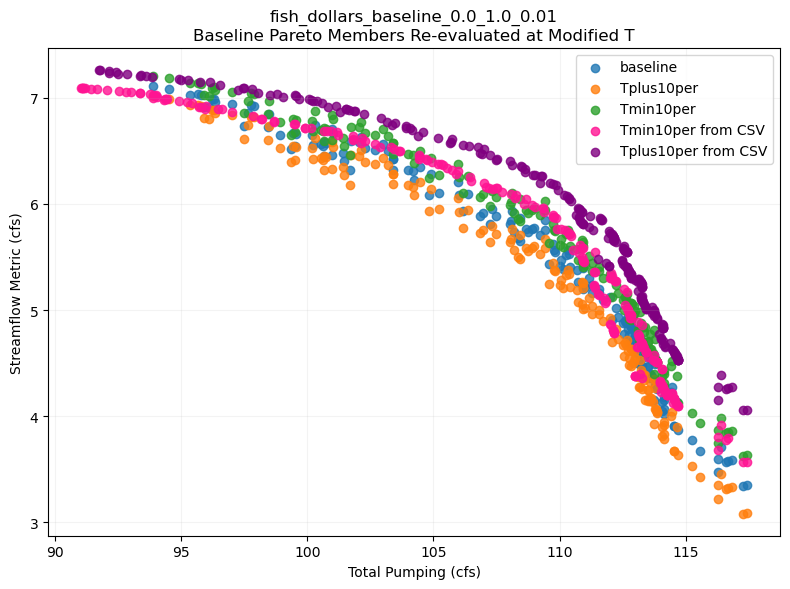

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/fish_dollars_baseline_0.0_1.0_0.01/fish_dollars_baseline_0.0_1.0_0.01_baseline_vs_Tpm10_streamflow_plot.png


In [38]:
if "streamflow_metric_cfs" in tradeoff_df.columns:
    sx0, sy0 = base_05["Total Pumping (cfs)"], base_05["Streamflow (cfs)"]
    sx1, sy1 = plus_05["Total Pumping (cfs)"], plus_05["Streamflow (cfs)"]
    sx2, sy2 = minus_05["Total Pumping (cfs)"], minus_05["Streamflow (cfs)"]
    plt.figure(figsize=(8, 6))

    for scenario_name, grp in tradeoff_df.groupby("scenario", sort=False):
        plt.scatter(
            grp["total_pumping_cfs"],
            grp["streamflow_metric_cfs"],
            label=scenario_name,
            alpha=0.8
        )

    plt.scatter(sx1, sy1, color="deeppink", alpha=0.8, label="Tmin10per from CSV")
    plt.scatter(sx2, sy2, color="purple", alpha=0.8, label="Tplus10per from CSV")

    plt.xlabel("Total Pumping (cfs)")
    plt.ylabel("Streamflow Metric (cfs)")
    plt.title(f"{RUN_NAME}\nBaseline Pareto Members Re-evaluated at Modified T")
    plt.legend()
    plt.grid(True, alpha=0.15)
    plt.tight_layout()

    streamflow_plot_file = OUTPUT_DIR / f"{RUN_NAME}_baseline_vs_Tpm10_streamflow_plot.png"
    plt.savefig(streamflow_plot_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", streamflow_plot_file)
else:
    print("BASELINE_FLOW_CFS is None, so the streamflow plot was skipped.")


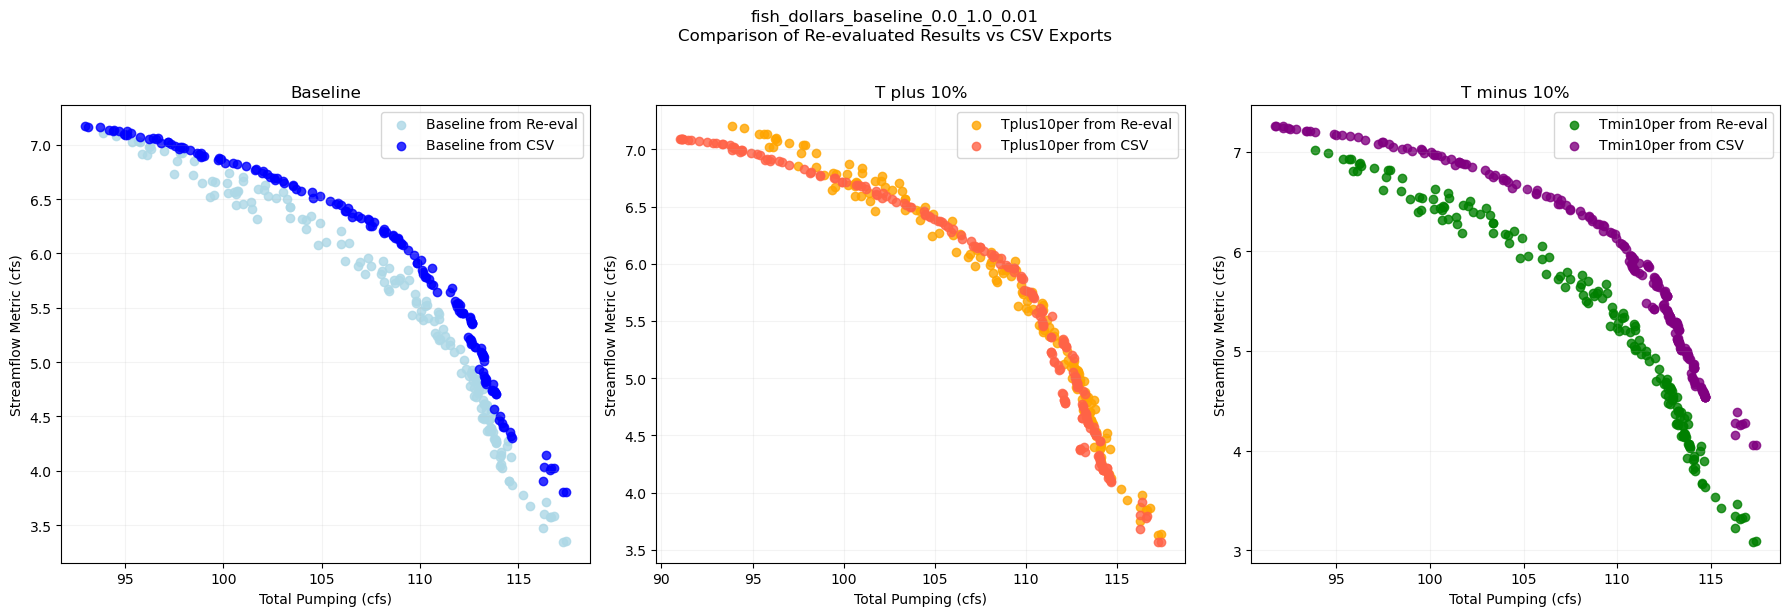

In [ ]:
if "streamflow_metric_cfs" in tradeoff_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].scatter(baseline["total_pumping_cfs"], baseline["streamflow_metric_cfs"], color="lightblue", alpha=0.8, label="Baseline from Re-eval")
    axes[0].scatter(sx0, sy0, color="blue", alpha=0.8, label="Baseline from CSV")

    axes[1].scatter(min10["total_pumping_cfs"], min10["streamflow_metric_cfs"], color="orange", alpha=0.8, label="Tplus10per from Re-eval")
    axes[1].scatter(sx1, sy1, color="tomato", alpha=0.8, label="Tplus10per from CSV")

    axes[2].scatter(plus10["total_pumping_cfs"], plus10["streamflow_metric_cfs"], color="green", alpha=0.8, label="Tmin10per from Re-eval")
    axes[2].scatter(sx2, sy2, color="purple", alpha=0.8, label="Tmin10per from CSV")

    for ax in axes:
        ax.set_xlabel("Total Pumping (cfs)")
        ax.set_ylabel("Streamflow Metric (cfs)")
        ax.grid(True, alpha=0.15)
        ax.legend() 

    axes[0].set_title("Baseline")
    axes[1].set_title("T plus 10%")
    axes[2].set_title("T minus 10%")
    plt.suptitle(f"{RUN_NAME}\nComparison of Re-evaluated Results vs CSV Exports", y=1.02)
    plt.tight_layout()

    comparison_plot_file = OUTPUT_DIR / f"{RUN_NAME}_streamflow_comparison_reval_vs_csv.png"
    plt.savefig(comparison_plot_file, dpi=300, bbox_inches="tight")
    plt.show()

## 7) Review the comparison tables

In [11]:
print("Tradeoff summary by scenario:")
tradeoff_summary_df


Tradeoff summary by scenario:


,statistic,total_pumping_cfs,depletion_metric_cfs,streamflow_metric_cfs,scenario
0,mean,108.412962,3.200409,5.399591,baseline
1,std,6.127039,1.019548,1.019548,baseline
2,25%,103.378823,2.207227,4.547763,baseline
3,50%,110.548948,3.189037,5.410963,baseline
4,75%,113.332342,4.052237,6.392773,baseline
5,max,117.415657,5.253924,7.108670,baseline
6,mean,108.412962,3.381715,5.218285,Tplus10per
7,std,6.127039,1.063600,1.063600,Tplus10per
8,25%,103.378823,2.342390,4.328229,Tplus10per
9,50%,110.548948,3.376533,5.223467,Tplus10per


In [12]:
print("Difference from baseline (member-level deltas) summary:")
tradeoff_delta_summary_df


Difference from baseline (member-level deltas) summary:


,statistic,total_pumping_cfs,depletion_metric_cfs,streamflow_metric_cfs,scenario
0,mean,0.0,0.181307,-0.181307,Tplus10per
1,std,0.0,0.044415,0.044415,Tplus10per
2,25%,0.0,0.138319,-0.217990,Tplus10per
3,50%,0.0,0.188107,-0.188107,Tplus10per
4,75%,0.0,0.217990,-0.138319,Tplus10per
5,max,0.0,0.262838,-0.094581,Tplus10per
6,mean,0.0,-0.192909,0.192909,Tmin10per
7,std,0.0,0.048354,0.048354,Tmin10per
8,25%,0.0,-0.233062,0.146100,Tmin10per
9,50%,0.0,-0.200205,0.200205,Tmin10per


## 8) Save output tables

In [13]:
member_q_df.to_csv(OUTPUT_DIR / f"{RUN_NAME}_pareto_members_q.csv")

for scenario_name, full_df in full_results.items():
    full_df.reset_index().to_csv(
        OUTPUT_DIR / f"{RUN_NAME}_{scenario_name}_reevaluated_full.csv",
        index=False
    )

tradeoff_df.to_csv(
    OUTPUT_DIR / f"{RUN_NAME}_tradeoff_comparison.csv",
    index=False
)

tradeoff_summary_df.to_csv(
    OUTPUT_DIR / f"{RUN_NAME}_tradeoff_summary_by_scenario.csv",
    index=False
)

tradeoff_delta_df.to_csv(
    OUTPUT_DIR / f"{RUN_NAME}_tradeoff_member_level_delta_vs_baseline.csv",
    index=False
)

tradeoff_delta_summary_df.to_csv(
    OUTPUT_DIR / f"{RUN_NAME}_tradeoff_delta_summary_vs_baseline.csv",
    index=False
)

print("Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f.name)


Saved files:
fish_dollars_baseline_0.0_1.0_0.01_Tmin10per_reevaluated_full.csv
fish_dollars_baseline_0.0_1.0_0.01_Tplus10per_reevaluated_full.csv
fish_dollars_baseline_0.0_1.0_0.01_baseline_reevaluated_full.csv
fish_dollars_baseline_0.0_1.0_0.01_baseline_vs_Tpm10_depletion_plot.png
fish_dollars_baseline_0.0_1.0_0.01_baseline_vs_Tpm10_streamflow_plot.png
fish_dollars_baseline_0.0_1.0_0.01_pareto_members_q.csv
fish_dollars_baseline_0.0_1.0_0.01_tradeoff_comparison.csv
fish_dollars_baseline_0.0_1.0_0.01_tradeoff_delta_summary_vs_baseline.csv
fish_dollars_baseline_0.0_1.0_0.01_tradeoff_member_level_delta_vs_baseline.csv
fish_dollars_baseline_0.0_1.0_0.01_tradeoff_summary_by_scenario.csv


## 9) Optional quick access to the scenario-specific full tables

These are convenient variables if you want to keep working in the notebook after the saved outputs are written.


In [14]:
baseline_full_df = full_results["baseline"].copy()
results_plus10_full_df = full_results["Tplus10per"].copy()
results_minus10_full_df = full_results["Tmin10per"].copy()

baseline_full_df.head()


,generation,ag_receipts,fish_prob,nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance,lpr:418:bdpl,...,lpr:94988:bdpl,lpr:95068:bdpl,lpr:total_proposed:bdpl,lpr:total_combined:bdpl,scenario,T_multiplier,total_pumping_cfs,depletion_metric_cfs,depletion_metric_source,streamflow_metric_cfs
member,,,,,,,,,,,,,,,,,,,,,
gen=47_member=5907_pso,50,9738960.0,0.719193,1,1.000000e+30,0.000002,0.000002,1,-999,0.000000,...,2.480979e-08,0.000007,1.517263,1.517263,baseline,1.0,94.529471,1.517263,lpr:total_combined:bdpl,7.082737
56,50,12446400.0,0.533346,1,1.000000e+30,0.000005,0.000005,1,-999,0.005462,...,2.480979e-08,0.000007,5.253924,5.253924,baseline,1.0,117.275577,5.253924,lpr:total_combined:bdpl,3.346076
64,50,12377800.0,0.567550,1,1.714570e-01,0.000008,0.000008,1,-999,0.006513,...,2.480979e-08,0.000007,4.888296,4.888296,baseline,1.0,116.394202,4.888296,lpr:total_combined:bdpl,3.711704
gen=40_member=5105_pso,50,12283000.0,0.583854,1,3.255550e-02,0.000016,0.000016,1,-999,0.006690,...,2.480979e-08,0.000007,4.927769,4.927769,baseline,1.0,115.563915,4.927769,lpr:total_combined:bdpl,3.672231
30,50,12433400.0,0.544694,1,1.239110e-01,0.000006,0.000006,1,-999,0.006837,...,2.480979e-08,0.000007,5.124914,5.124914,baseline,1.0,116.273157,5.124914,lpr:total_combined:bdpl,3.475086
